# Elastic Net

In [ ]:
# import potrebnych kniznic a konfiguracia notebooku
%load_ext autoreload
%autoreload 2

import importlib
import warnings

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path

import functions.functions_elastic_net
#importlib.reload(functions.functions_elastic_net)
from functions.functions_elastic_net import rolling_forecast_elastic_net, evaluate_forecast

import other.cred
#importlib.reload(other.cred)
from other.cred import DATA_PATH_CRED

import functions.functions_general
importlib.reload(functions.functions_general)
from functions.functions_general import forecast_plot

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

plt.rcParams.update({
    "figure.figsize": (13, 10),
    "figure.dpi": 110,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 11,
})


print("Importy uspesne.")

Importy uspesne.


In [33]:
# konfiguracia a stiahnutie dat
main_dir = Path(DATA_PATH_CRED)
data_mod = "data_mod.csv"
pp_orig = "data.xlsx"
DATA_PATH_DATA_MOD  = main_dir / data_mod
DATA_PATH_DATA = main_dir / pp_orig
SHEET_NAME_PP = "pp"
SHEET_NAME_EXOG = "exog"
TEST_SIZE = 24
RANDOM_STATE = 24
TARGET_VAR = "pp_sa_ca_jd"

df_raw = pd.read_csv(DATA_PATH_DATA_MOD)
df_raw["datum"] = pd.to_datetime(df_raw["datum"])
df_raw = df_raw.set_index("datum").sort_index()
df_raw = df_raw.asfreq("MS")
df = df_raw.copy()

df_pp = pd.read_excel(DATA_PATH_DATA,SHEET_NAME_PP)
df_pp = df_pp.set_index("datum").sort_index()
df_pp = df_pp.asfreq("MS")

df_exog = pd.read_excel(DATA_PATH_DATA,SHEET_NAME_EXOG)
df_exog = df_exog.set_index("datum").sort_index()
df_exog = df_exog.asfreq("MS")
df_exog = df_exog.drop(columns=["datum"], errors="ignore")

In [34]:
X = df.drop(columns = ["pp_nonsa", "pp_sa_orig", TARGET_VAR])
y = df[TARGET_VAR]
init_train_size = len(y) - TEST_SIZE
last_train_value = float(df_pp[TARGET_VAR].iloc[init_train_size - 1])


In [4]:
results_elnet, models_elnet, coef_hist, best_params_hist = rolling_forecast_elastic_net(
    X=X,
    y_diff=y,
    level_series=df_pp[TARGET_VAR],
    initial_train_size= init_train_size,
    last_train_value=last_train_value,
    refit_every=1,
    reconstruction="onestep"
)

RMSE (diferencia): 2.1318
RMSE (level, onestep rekonstrukcia): 2.1318
MAPE (level, WMAPE): 1.55%
ME (level): -0.1344


In [5]:
selected_counts = coef_hist.groupby("forecast_date")["n_selected"].first()
print(selected_counts.describe())

count    24.000000
mean     14.791667
std       2.206299
min      11.000000
25%      13.000000
50%      15.000000
75%      16.000000
max      20.000000
Name: n_selected, dtype: float64


In [6]:
top_feat = coef_hist[coef_hist["selected"]].groupby("feature")["abs_coef"].mean().sort_values(ascending = False)
top_feat


feature
trzby_priemysel_sa              1.375672
crisis_dummy                    1.112298
export_celkovy_sa               1.064556
unem_prod                       0.196755
uvery_celkom                    0.155416
expected_employment             0.146595
hdd                             0.139837
cdd                             0.126647
sh_prices_non_sa                0.110207
kurz_usd_eur                    0.090945
economic_sentiment              0.069880
cpi_nsa                         0.060292
vklady_nefinancne_podniky       0.054679
sadzba_3m_euribor               0.034134
inflation                       0.025310
expected_industry_production    0.023738
expected_product_prices         0.014010
oil_price_eur                   0.012277
oil_europe_usd                  0.008992
foreign_demand_sa               0.008678
ipcv_priemysel                  0.002076
Name: abs_coef, dtype: float64

In [52]:
Y_axis = [results_elnet["actual_diff"], results_elnet["predicted_diff"], results_elnet["actual_level"], results_elnet["predicted_level"]]
X_axis = [results_elnet.index] * len(Y_axis)
labels = ["Povodna PP", "Predikovana PP"] * len(Y_axis)
titles = ["Priemyselna produkcia (diferencovana)", "Priemyselna produkcia"]
colors = ["#0000FF", "#FF0000"] * len(Y_axis)
linestyles = ["-","--"] * len(Y_axis)
linewidths = [] * len(Y_axis)
alphas = [0.8,1] * len(Y_axis)
fig_size = [18,9]
num_rows = 2
num_cols = 1

In [54]:
s_comb = pd.concat([results_elnet["actual_diff"], results_elnet["predicted_diff"]],axis= 1)
s_comb

,actual_diff,predicted_diff
date,,
2024-01-01,-1.896695,-3.602249
2024-02-01,-2.138195,-2.819647
2024-03-01,0.355519,1.354097
2024-04-01,2.169302,2.972479
2024-05-01,0.452961,0.052303
2024-06-01,0.526767,-0.058185
2024-07-01,-0.283782,-1.312371
2024-08-01,0.229587,-0.119308
2024-09-01,-2.334882,0.695831


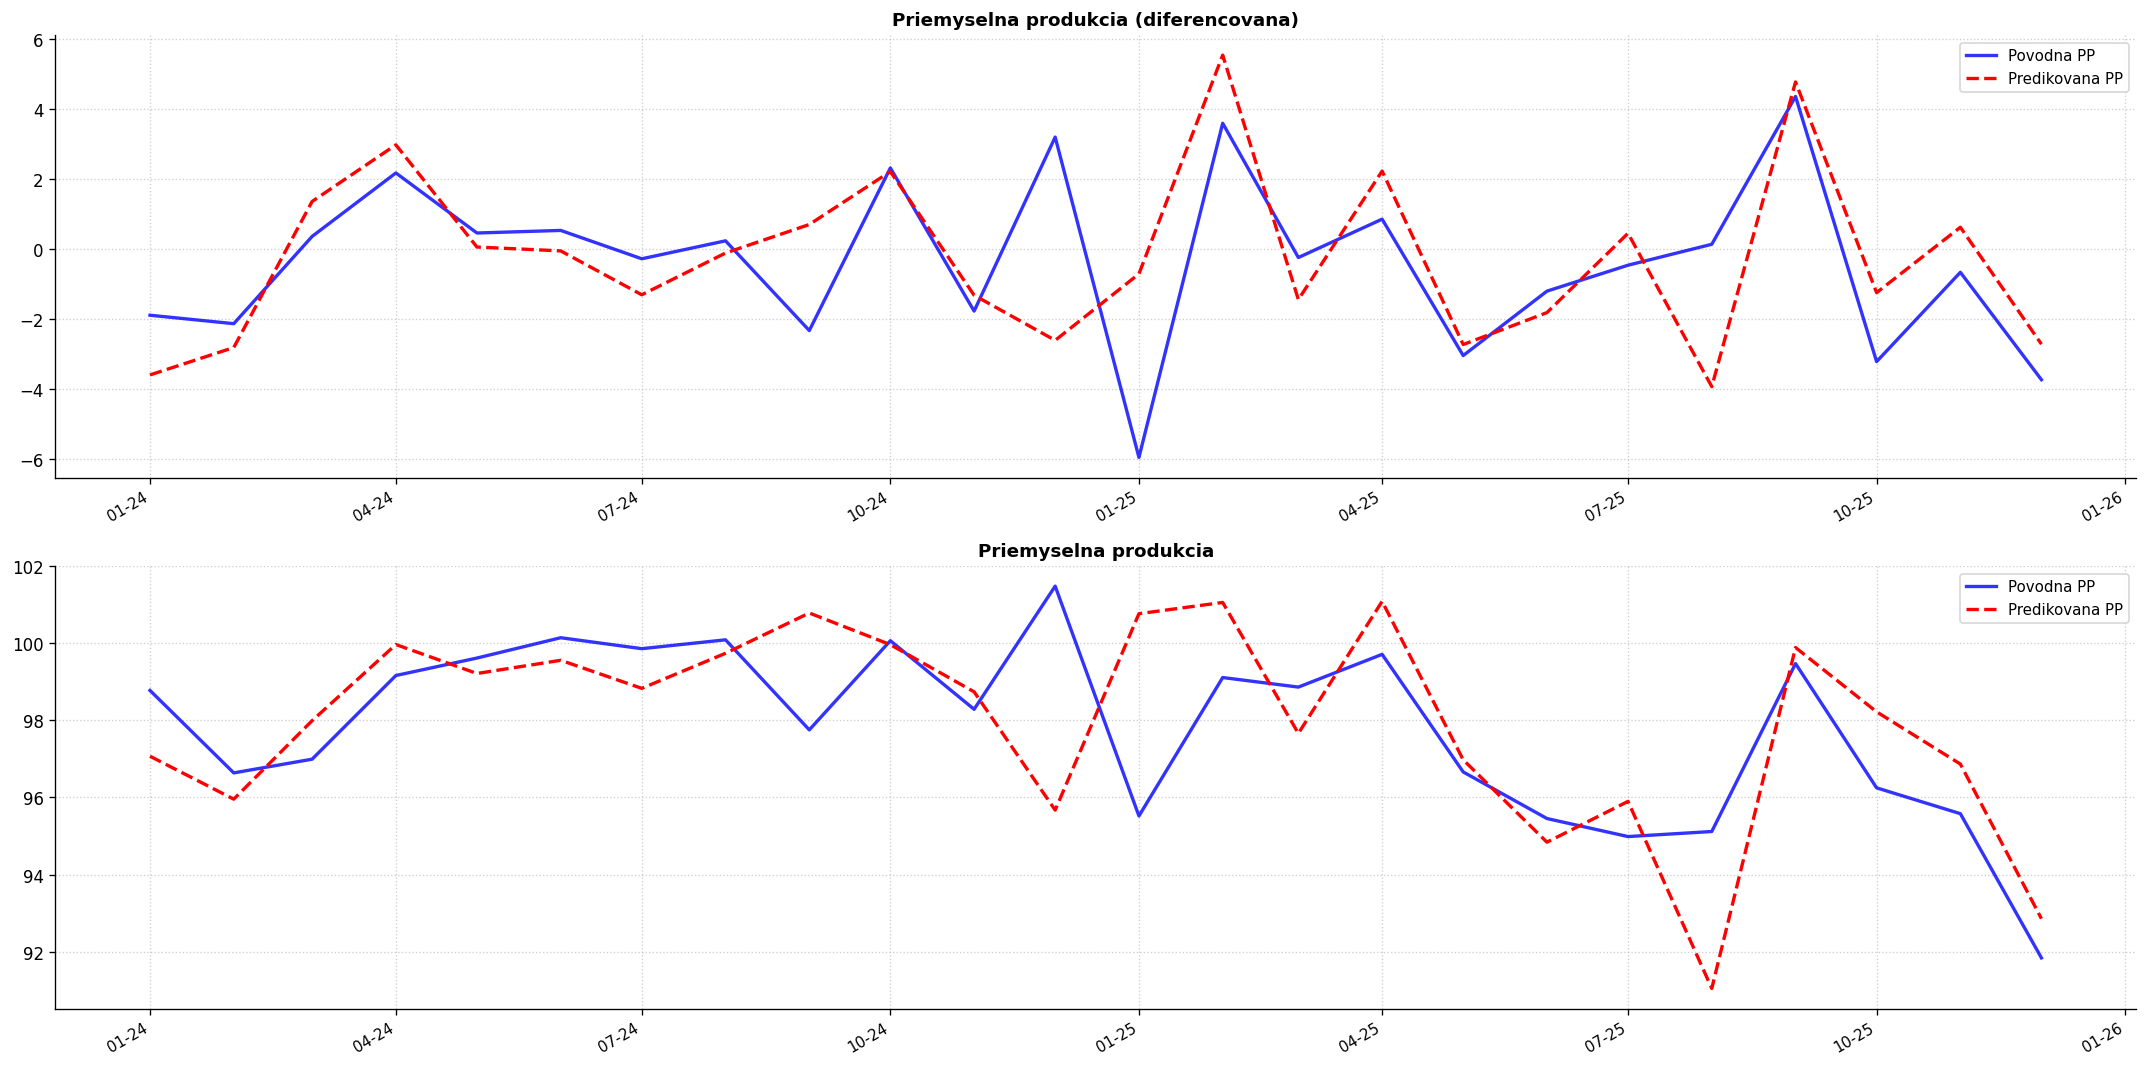

In [63]:
import functions_general
importlib.reload(functions_general)
from functions_general import forecast_plot
forecast_plot(X_axis,Y_axis,titles, labels, colors, linestyles, linewidths, alphas,fig_size, num_rows, num_cols)

In [10]:
print(plt.style.available)

['Solarize_Light2', '_classic_test_patch', '_mpl-gallery', '_mpl-gallery-nogrid', 'bmh', 'bright', 'cjk-jp-font', 'cjk-kr-font', 'cjk-sc-font', 'cjk-tc-font', 'classic', 'dark_background', 'discrete-rainbow-1', 'discrete-rainbow-10', 'discrete-rainbow-11', 'discrete-rainbow-12', 'discrete-rainbow-13', 'discrete-rainbow-14', 'discrete-rainbow-15', 'discrete-rainbow-16', 'discrete-rainbow-17', 'discrete-rainbow-18', 'discrete-rainbow-19', 'discrete-rainbow-2', 'discrete-rainbow-20', 'discrete-rainbow-21', 'discrete-rainbow-22', 'discrete-rainbow-23', 'discrete-rainbow-3', 'discrete-rainbow-4', 'discrete-rainbow-5', 'discrete-rainbow-6', 'discrete-rainbow-7', 'discrete-rainbow-8', 'discrete-rainbow-9', 'fast', 'fivethirtyeight', 'ggplot', 'grayscale', 'grid', 'high-contrast', 'high-vis', 'ieee', 'latex-sans', 'light', 'muted', 'nature', 'no-latex', 'notebook', 'petroff10', 'pgf', 'retro', 'russian-font', 'sans', 'scatter', 'science', 'seaborn-v0_8', 'seaborn-v0_8-bright', 'seaborn-v0_8-co